Loading data...


/Users/shunkhwn/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/shunkhwn/Library/Python/3.9/lib/python/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Loading models...
Generating predictions...
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

BASELINE MODEL ACCURACY:  81.81%
OPTIMIZED MODEL ACCURACY: 88.38%

--- OPTIMIZED MODEL PERFORMANCE REPORT ---
               precision    recall  f1-score   support

   Electronic       0.87      0.90      0.89       205
 Experimental       0.81      0.90      0.86       200
         Folk       0.92      0.88      0.90       185
      Hip-Hop       0.94      0.85      0.89       206
 Instrumental       0.83      0.88      0.85       204
International       0.93      0.92      0.93       211
          Pop       0.91      0.81      0.86       202
         Rock       0.89      0.93      0.91       187

     accuracy                           0.88      1600
    macro avg       0.89      0.88      0.88      1600
 weighted avg       0.89      0.88      0.88      1600



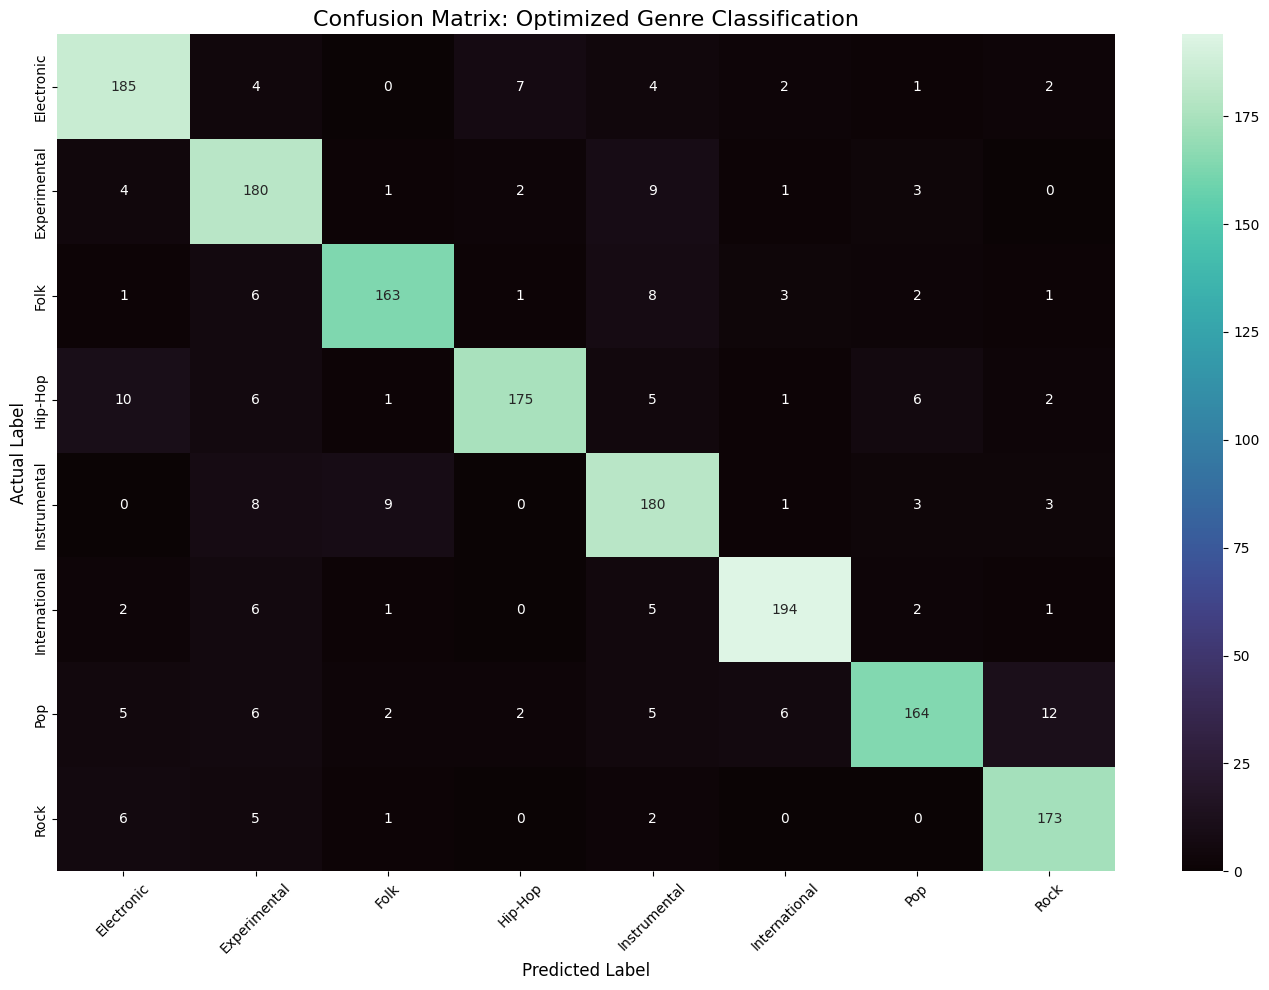

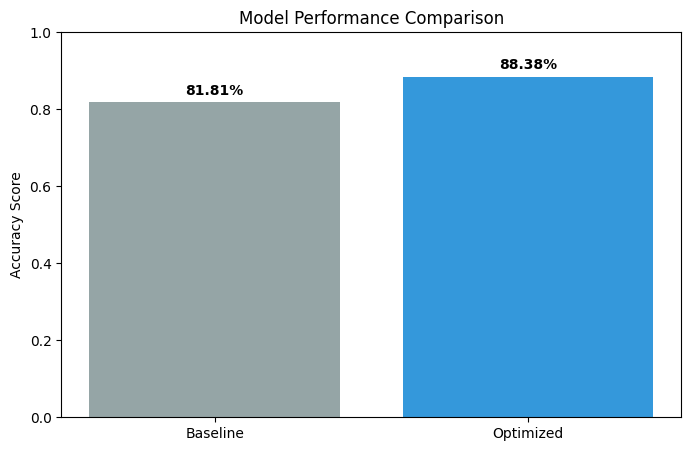

In [4]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
import os

# 1. Load Data
DATA_PATH = "data.json" 
BASELINE_PATH = "baseline_model.h5"
OPTIMIZED_PATH = "optimized_model.h5"

print("Loading data...")
with open(DATA_PATH, "r") as fp:
    data = json.load(fp)

X = np.array(data["mfcc"])[..., np.newaxis]
y = np.array(data["labels"])
mapping = data["mapping"]

# 2. Split into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Load Models
print("Loading models...")
baseline = tf.keras.models.load_model(BASELINE_PATH)
optimized = tf.keras.models.load_model(OPTIMIZED_PATH)

# 4. Generate Predictions
print("Generating predictions...")
y_pred_opt = np.argmax(optimized.predict(X_test), axis=1)
y_pred_base = np.argmax(baseline.predict(X_test), axis=1)

# 5. Accuracy Comparison
acc_base = accuracy_score(y_test, y_pred_base)
acc_opt = accuracy_score(y_test, y_pred_opt)

print("\n" + "="*40)
print(f"BASELINE MODEL ACCURACY:  {acc_base*100:.2f}%")
print(f"OPTIMIZED MODEL ACCURACY: {acc_opt*100:.2f}%")
print("="*40)

# 6. FIXED: Detailed Classification Report (Optimized Only)
print("\n--- OPTIMIZED MODEL PERFORMANCE REPORT ---")

# Get unique labels present in the test set to avoid the "8 vs 16" mismatch
unique_labels = np.unique(y_test)
target_names = [mapping[i] for i in unique_labels]

print(classification_report(y_test, y_pred_opt, labels=unique_labels, target_names=target_names))

# 7. FIXED: Visualizing the Confusion Matrix
plt.figure(figsize=(14, 10))

# We explicitly pass the unique labels to keep the matrix square and labeled correctly
cm = confusion_matrix(y_test, y_pred_opt, labels=unique_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='mako', 
            xticklabels=target_names, yticklabels=target_names)

plt.title("Confusion Matrix: Optimized Genre Classification", fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. Comparison Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(['Baseline', 'Optimized'], [acc_base, acc_opt], color=['#95a5a6', '#3498db'])
plt.ylabel('Accuracy Score')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.0)
for i, v in enumerate([acc_base, acc_opt]):
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center', fontweight='bold')
plt.show()